# SynthACticBench O1 with `min_samples_split=1`

Problem seed 53, five SMAC seeds, and regret relative to the known global minimum. The plots show mean best regret with 95% confidence intervals and per-seed boxplots every 100 trials.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/04_reduce_min_split")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "staged_leaf_3_2_1")
SEEDS = tuple(range(5))
CHECKPOINTS = (100, 200, 300, 400, 500)
LABELS = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}

In [2]:
def load_results(policy):
    by_seed = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == 500:
            if seed not in by_seed or path.stat().st_mtime > by_seed[seed][0]:
                by_seed[seed] = (path.stat().st_mtime, result)
    missing = sorted(set(SEEDS) - set(by_seed))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}, seeds={missing}")
    return {seed: by_seed[seed][1] for seed in SEEDS}


results = {policy: load_results(policy) for policy in POLICIES}
for runs in results.values():
    for result in runs.values():
        assert result["problem_seed"] == 53
        assert result["min_samples_split"] == 1
        assert min(result["regret"]) >= -1e-8
print(f"Loaded {sum(len(runs) for runs in results.values())}/20 trajectories.")
print("Known global minimum:", results["fixed_leaf_1"][0]["f_min"])

Loaded 20/20 trajectories.
Known global minimum: -267554.1673176964


In [3]:
# Verify all paired settings and fixed-leaf-3 prefixes.
comparison_fields = (
    "problem", "problem_seed", "instance_seed", "pythonhashseed",
    "n_instances", "instance_map", "n_trials", "min_samples_split", "f_min",
)
reference = results["fixed_leaf_3"][0]
for policy, runs in results.items():
    for seed, result in runs.items():
        for field in comparison_fields:
            assert result[field] == reference[field], (policy, seed, field)
        assert result["smac_seed"] == seed
for seed in SEEDS:
    assert (
        results["staged_leaf_3_2_1"][seed]["objective_value"][:150]
        == results["fixed_leaf_3"][seed]["objective_value"][:150]
    ), seed
print("All paired-run checks passed.")

All paired-run checks passed.


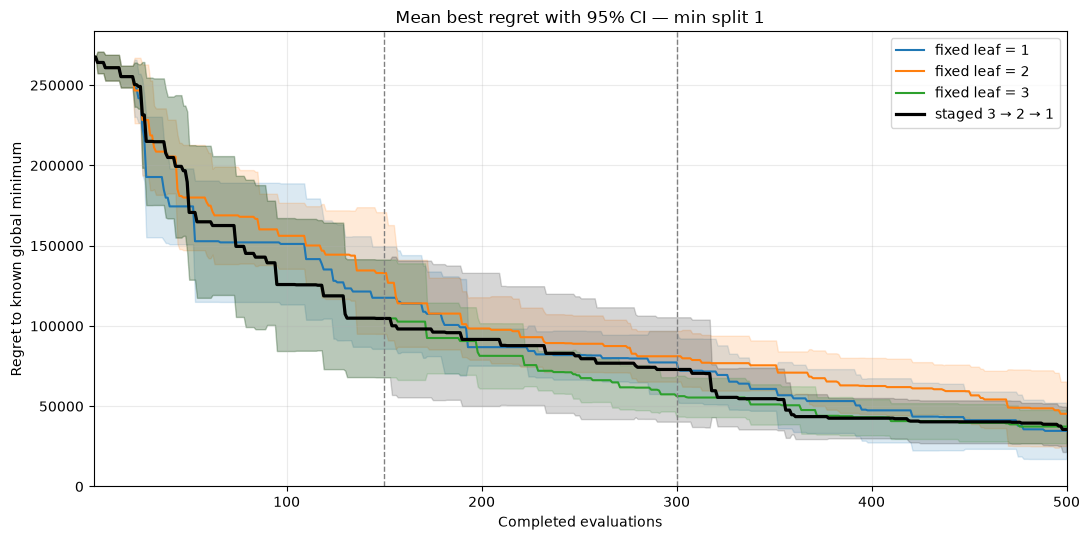

In [4]:
rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        rows.extend(
            {"policy": policy, "smac_seed": seed, "iteration": i, "best_regret": regret}
            for i, regret in zip(result["iteration"], result["best_regret"])
        )
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_regret"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(11, 5.5))
for policy in POLICIES:
    data = summary[summary["policy"] == policy]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    line = ax.plot(x, mean, label=LABELS[policy], **style)[0]
    ax.fill_between(x, np.maximum(0, mean - ci), mean + ci, color=line.get_color(), alpha=0.16)
ax.axvline(150, color="grey", linestyle="--", linewidth=1)
ax.axvline(300, color="grey", linestyle="--", linewidth=1)
ax.set(title="Mean best regret with 95% CI — min split 1", xlabel="Completed evaluations", ylabel="Regret to known global minimum", xlim=(1, 500))
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

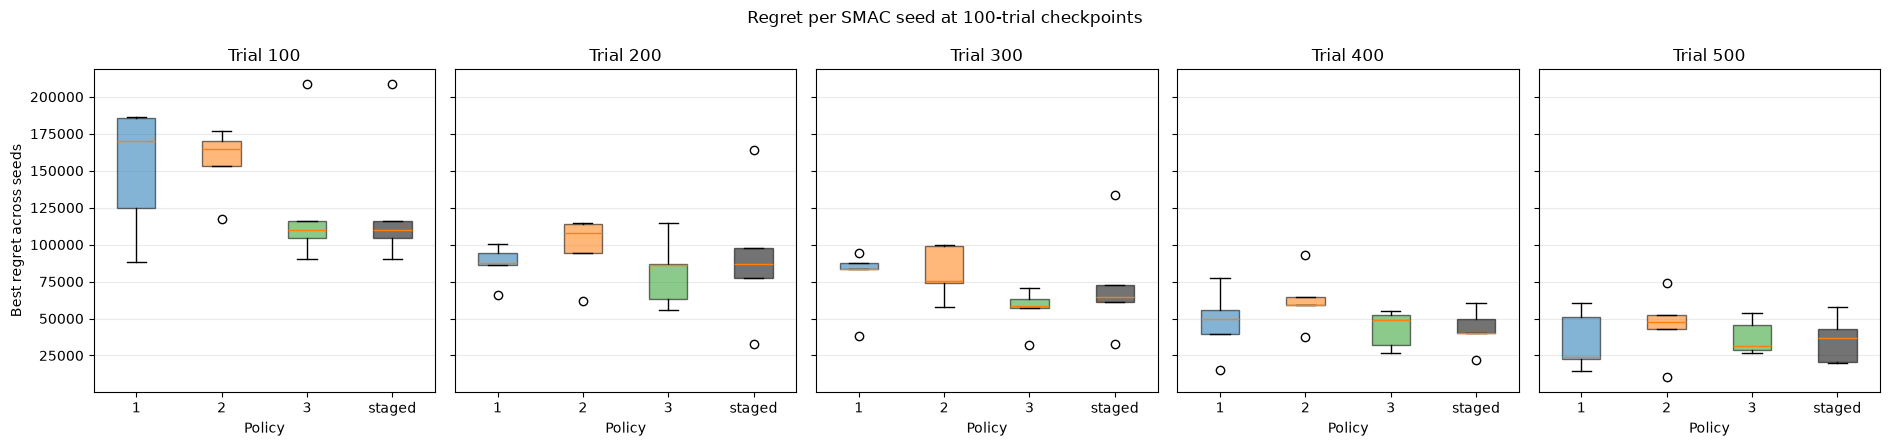

In [5]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(19, 4.5), sharey=True)
for ax, checkpoint in zip(axes, CHECKPOINTS):
    values = [
        [results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS]
        for policy in POLICIES
    ]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=["1", "2", "3", "staged"])
    for box, color in zip(boxes["boxes"], ("C0", "C1", "C2", "black")):
        box.set(facecolor=color, alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.set_xlabel("Policy")
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Best regret across seeds")
fig.suptitle("Regret per SMAC seed at 100-trial checkpoints")
plt.tight_layout()
plt.show()

In [6]:
(
    trajectories[trajectories["iteration"].isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_regret"]
    .agg(["mean", "std", "min", "median", "max"])
)

mean           std            min  \
iteration policy                                                          
100       fixed_leaf_1       151097.759790  43030.700062   88562.054742   
          fixed_leaf_2       156159.754774  23449.120374  117177.667369   
          fixed_leaf_3       125805.684848  47245.691990   90406.646313   
          staged_leaf_3_2_1  125805.684848  47245.691990   90406.646313   
200       fixed_leaf_1        86797.185508  13157.074573   65593.074687   
          fixed_leaf_2        98419.286907  22205.680590   61547.309564   
          fixed_leaf_3        81394.497072  23198.736946   55442.755310   
          staged_leaf_3_2_1   91609.921103  47331.124041   32550.185748   
300       fixed_leaf_1        77277.119296  22390.221641   38009.606833   
          fixed_leaf_2        81118.273564  18004.624502   57488.890174   
          fixed_leaf_3        56275.478907  14513.538051   32006.761929   
          staged_leaf_3_2_1   72903.970822  37112.717504   32492.470788   
400       fixed_leaf_1        47424.256559  22822.373799   14995.976992   
          fixed_leaf_2        62589.090882  19966.994599   37385.122812   
          fixed_leaf_3        43149.035830  12811.185357   26988.591710   
          staged_leaf_3_2_1   42547.429934  14359.507291   21752.402258   
500       fixed_leaf_1        34650.175745  20002.916089   14812.467730   
          fixed_leaf_2        45288.487353  22940.683315   10193.255947   
          fixed_leaf_3        37348.609639  11830.947509   26608.490093   
          staged_leaf_3_2_1   35554.210310  16054.827387   19834.409384   

                                    median            max  
iteration policy                                           
100       fixed_leaf_1       169772.640835  186491.451856  
          fixed_leaf_2       164365.852278  176571.460474  
          fixed_leaf_3       109664.840998  208629.946240  
          staged_leaf_3_2_1  109664.840998  208629.946240  
200       fixed_leaf_1        87230.086050  100342.153830  
          fixed_leaf_2       107617.003392  114732.919528  
          fixed_leaf_3        86387.784019  114612.445770  
          staged_leaf_3_2_1   86574.923145  163844.448837  
300       fixed_leaf_1        83704.385217   94246.403183  
          fixed_leaf_2        75593.442506   99755.779180  
          fixed_leaf_3        58622.267271   70534.234603  
          staged_leaf_3_2_1   64502.108609  133451.388736  
400       fixed_leaf_1        49358.341660   77335.772461  
          fixed_leaf_2        59033.176004   93076.328779  
          fixed_leaf_3        48682.680020   55380.449384  
          staged_leaf_3_2_1   40461.330353   60625.010581  
500       fixed_leaf_1        23703.912144   60684.477077  
          fixed_leaf_2        47429.944055   73789.149164  
          fixed_leaf_3        31732.000543   53676.560212  
          staged_leaf_3_2_1   36523.310021   57899.525396